<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower

## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [63]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.47846033941944155


In [64]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.0421967159248899
95% confidence interval: (np.float64(-0.5450733877678422), np.float64(-0.010926612232162292))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.042998380088903033
Degrees of freedom: 17.02484516235282
95% confidence interval: (np.float64(-0.5461741394750226), np.float64(-0.009825860524981911))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


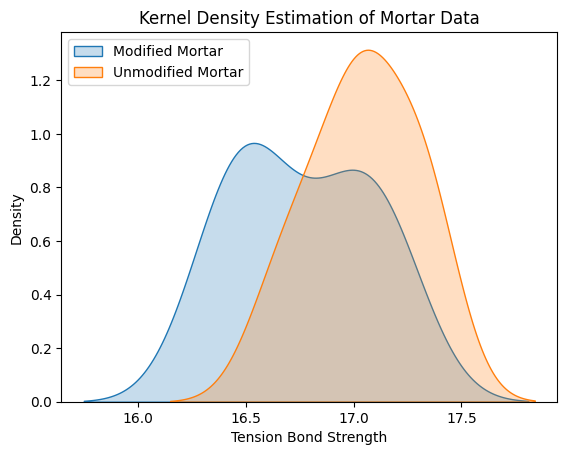

In [65]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

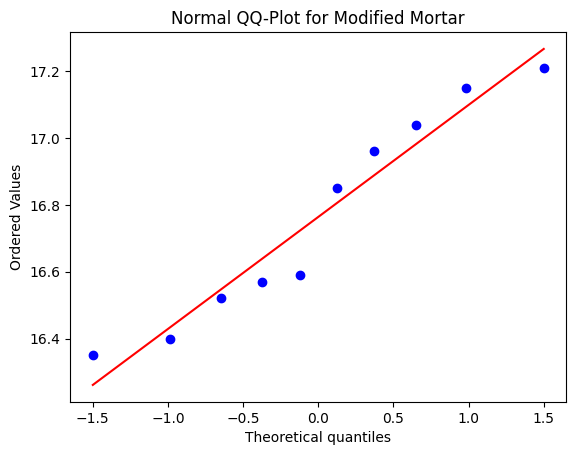

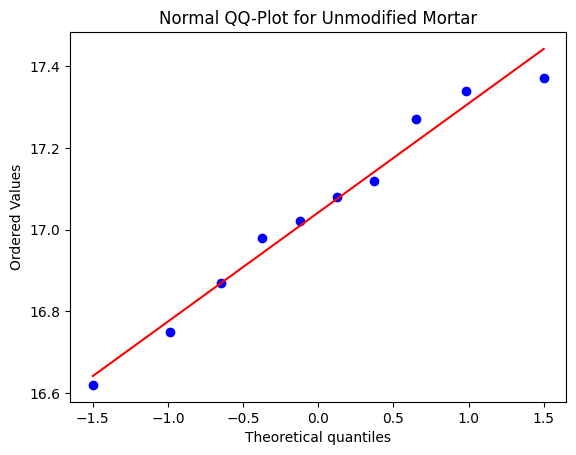

In [66]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [67]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332801846344, p-value=0.3456968630049325
Shapiro-Wilk Test for y2: Statistic=0.9626192871584892, p-value=0.8152773063551302


In [68]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.543644227812653


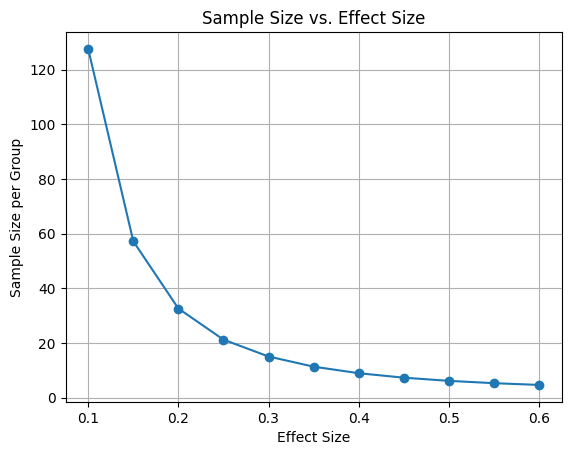

In [69]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [70]:
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

df20.head()

,Days
0,108
1,124
2,124
3,106
4,115


In [71]:
df20.shape[0]

10

$\mu$ is the population mean shelf life. We use the one-sided hypotheses
for the test
$$
H_0:\mu\le 120,\qquad H_1:\mu>120.
$$
We do not know the variance and the sample size is small - t-test it is

In [72]:
x20 = df20["Days"].to_numpy(dtype=float)
n20 = len(x20)
mean20 = np.mean(x20)
s20 = np.std(x20, ddof=1)
se20 = s20 / np.sqrt(n20)
df_20 = n20 - 1

t20 = (mean20 - 120) / se20
p20 = stats.t.sf(t20, df_20)
ci20 = stats.t.interval(0.99, df=df_20, loc=mean20, scale=se20)

print(f"n = {n20}")
print(f"Sample mean = {mean20:.3f} days")
print(f"Sample standard deviation = {s20:.3f} days")
print(f"t = {t20:.4f}, df = {df_20}")
print(f"One-sided p-value = {p20:.6f}")
print(f"99% two sided CI for mu = ({ci20[0]:.3f}, {ci20[1]:.3f}) days")


n = 10
Sample mean = 131.000 days
Sample standard deviation = 19.545 days
t = 1.7798, df = 9
One-sided p-value = 0.054409
99% two sided CI for mu = (110.914, 151.086) days


In [73]:
# Calculate one-sided 99% confidence bounds
alpha20 = 0.01

# t critical value for a one-sided test at 1 - alpha
t_crit_one_sided = stats.t.ppf(1 - alpha20, df=df_20)

# Lower one-sided 99% confidence interval: [L, +inf) -- THE ONE WE WANT
lower_bound = mean20 - t_crit_one_sided * se20

print(f"99% Lower One-Sided Confidence Interval: ([{lower_bound:.3f}, +inf) days")

99% Upper One-Sided Confidence Interval: ([113.562, +inf) days


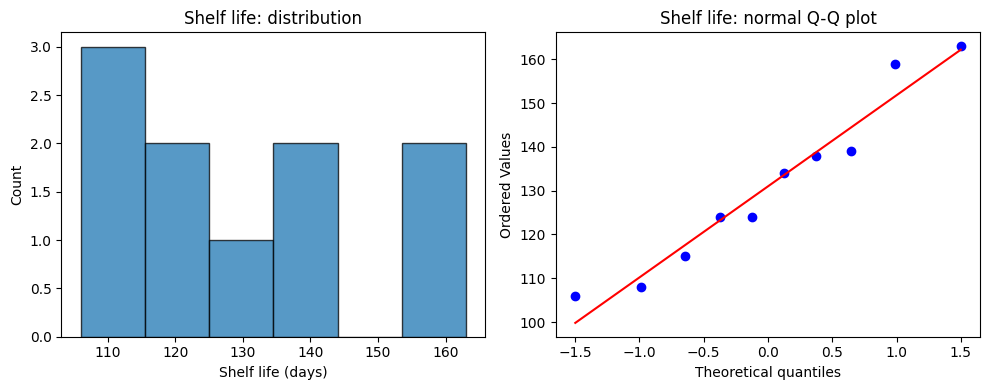

Shapiro-Wilk: W = 0.9365, p-value = 0.5152


In [74]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(x20, bins=6, edgecolor="black", alpha=0.75)
ax[0].set_title("Shelf life: distribution")
ax[0].set_xlabel("Shelf life (days)")
ax[0].set_ylabel("Count")
stats.probplot(x20, dist="norm", plot=ax[1])
ax[1].set_title("Shelf life: normal Q-Q plot")
plt.tight_layout()
plt.show()

W20, p_shapiro20 = shapiro(x20)
print(f"Shapiro-Wilk: W = {W20:.4f}, p-value = {p_shapiro20:.4f}")

The sample mean is 131.0 days with the one sided test giving $p\approx0.0544$, which is larger than $\alpha=0.01$. Thus the data dont show evidence at the 1% level that the population mean shelf life exceeds 120 days. For the 99% CI it depends if we take one sided or two sided. The twosided CI is approximately $(110.91,151.09)$ days and includes 120, but closer to our test is the 99% lower one-sided CI with values in the range of $[113.562, +\inf)$ days, which again contains the tested value of 120 days. The Q-Q plot appears roughly liner and Shapiro-Wilk test of normality gives $p\approx0.515$, so there is no evidence of a serious departure from normality. But the sample size is very small. With only 10 observations a strong skew or some outliers would matter greately.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [75]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


Let $\mu_1$ and $\mu_2$ denote the mean etch rates. We wish to test
$$
H_0:\mu_1=\mu_2,\qquad H_1:\mu_1\ne\mu_2
$$
with the pooled two-sample $t$-test assuming equal variances (as was also shown in the mortar case). We construct a CI for $\mu_1-\mu_2$. For the part (d), Cohen's standardized effect is formed using the pooled standard deviation.

In [76]:
x21 = df21["Solution1"].to_numpy(dtype=float)
y21 = df21["Solution2"].to_numpy(dtype=float)
n1_21, n2_21 = len(x21), len(y21)
mean1_21, mean2_21 = np.mean(x21), np.mean(y21)
var1_21, var2_21 = np.var(x21, ddof=1), np.var(y21, ddof=1)

sp2_21 = ((n1_21 - 1)*var1_21 + (n2_21 - 1)*var2_21) / (n1_21 + n2_21 - 2)
sp_21 = np.sqrt(sp2_21)
se21 = sp_21 * np.sqrt(1/n1_21 + 1/n2_21)
df_21 = n1_21 + n2_21 - 2
diff21 = mean1_21 - mean2_21
t21 = diff21 / se21
p21 = 2 * stats.t.sf(abs(t21), df_21)
ci21 = stats.t.interval(0.95, df=df_21, loc=diff21, scale=se21)

print(f"Mean solution 1 = {mean1_21:.4f}")
print(f"Mean solution 2 = {mean2_21:.4f}")
print(f"Pooled SD = {sp_21:.4f}")
print(f"Difference (mu1 - mu2) estimate = {diff21:.4f}")
print(f"t = {t21:.4f}, df = {df_21}, two-sided p-value = {p21:.6f}")
print(f"95% CI for mu1 - mu2 = ({ci21[0]:.4f}, {ci21[1]:.4f})")

Mean solution 1 = 9.9500
Mean solution 2 = 10.3625
Pooled SD = 0.3584
Difference (mu1 - mu2) estimate = -0.4125
t = -2.3016, df = 14, two-sided p-value = 0.037236
95% CI for mu1 - mu2 = (-0.7969, -0.0281)


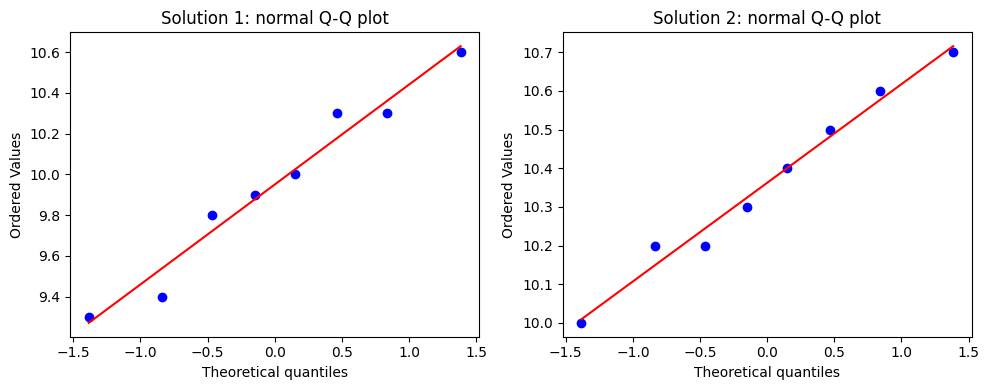

Shapiro-Wilk solution 1: W=0.9549, p=0.7603
Shapiro-Wilk solution 2: W=0.9768, p=0.9454
SD solution 1 = 0.4504; SD solution 2 = 0.2326
Supplementary two-sided F-test: F=3.7492, p=0.1024
Observed standardized effect |d| = 1.1508
Power with n=8 per group = 0.5724
Required n per group for Delta=0.3 and power >= 0.90: 31
Power at n=31: 0.9001


In [77]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(x21, dist="norm", plot=ax[0])
ax[0].set_title("Solution 1: normal Q-Q plot")
stats.probplot(y21, dist="norm", plot=ax[1])
ax[1].set_title("Solution 2: normal Q-Q plot")
plt.tight_layout()
plt.show()

W1_21, pW1_21 = shapiro(x21)
W2_21, pW2_21 = shapiro(y21)
F21 = var1_21 / var2_21
pF21 = 2 * min(stats.f.cdf(F21, n1_21-1, n2_21-1), stats.f.sf(F21, n1_21-1, n2_21-1))
print(f"Shapiro-Wilk solution 1: W={W1_21:.4f}, p={pW1_21:.4f}")
print(f"Shapiro-Wilk solution 2: W={W2_21:.4f}, p={pW2_21:.4f}")
print(f"SD solution 1 = {np.sqrt(var1_21):.4f}; SD solution 2 = {np.sqrt(var2_21):.4f}")
print(f"Supplementary two-sided F-test: F={F21:.4f}, p={pF21:.4f}")

power_analysis = TTestIndPower()
observed_effect21 = abs(diff21) / sp_21
power21 = power_analysis.power(effect_size=observed_effect21, nobs1=n1_21, ratio=n2_21/n1_21, alpha=0.05, alternative="two-sided")
required_n21 = power_analysis.solve_power(effect_size=0.3/sp_21, alpha=0.05, power=0.90, ratio=1.0, alternative="two-sided")
required_n21_int = int(np.ceil(required_n21))
check_power21 = power_analysis.power(effect_size=0.3/sp_21, nobs1=required_n21_int, ratio=1.0, alpha=0.05, alternative="two-sided")

print(f"Observed standardized effect |d| = {observed_effect21:.4f}")
print(f"Power with n=8 per group = {power21:.4f}")
print(f"Required n per group for Delta=0.3 and power >= 0.90: {required_n21_int}")
print(f"Power at n={required_n21_int}: {check_power21:.4f}")

The pooled t-test has resulting statistic of $t\approx-2.302$ with $p\approx0.0372$, so at $\alpha=0.05$ the claim of the equivalence of the means is rejected. Solution 2 has the larger mean. The 95% CI for $\mu_1-\mu_2$ is roughly $(-0.7969,-0.0281)$ mils/min, so zero is not contained. Now, it is important what is a pratically important difference. Maybe a difference of 0,1 mils/min is actually a weak enough improvement related to the solution cost to not matter, or it is bottlenecked elsewhere and usch a small improvement would not help. Both Q-Q plots are compatible with normality (Shapiro-Wilk p-values about 0.760 and 0.945). Solution 1 appears at a first glance as more variable, but the supplementary F-test does not reject equal variances at 5% ($p\approx0.102$). With only 8 observations per group this check has limited power, so it should be maybe taken with a grain of salt? @Jiří Franc. Using the estimated effect, the original test power is about 0.572 so that means a high risk of a Type II error and a lower replicability?  To detect $\Delta=0.3$ with power at least 0.90 at $\alpha=0.05$, about 31 wafers per solution are required.


### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [78]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


First we test the equality of the variances with the two-sided $F$-test,
$$
H_0:\sigma_1^2=\sigma_2^2,\qquad H_1:\sigma_1^2\ne\sigma_2^2.
$$
The result of this test then determines whether the pooled two-sample $t$-test is appropriate for testing $H_0:\mu_1=\mu_2$ against $H_1:\mu_1\ne\mu_2$ or if we should reach for the Welch's test. $F$-test again assumes normality so Q-Q plots and Shapiro-Wilk checks are important here.

In [79]:
x26 = df26["Type1"].to_numpy(dtype=float)
y26 = df26["Type2"].to_numpy(dtype=float)
n1_26, n2_26 = len(x26), len(y26)
mean1_26, mean2_26 = np.mean(x26), np.mean(y26)
var1_26, var2_26 = np.var(x26, ddof=1), np.var(y26, ddof=1)

F26 = var1_26 / var2_26
pF26 = 2 * min(stats.f.cdf(F26, n1_26-1, n2_26-1), stats.f.sf(F26, n1_26-1, n2_26-1))
print(f"Variance Type 1 = {var1_26:.4f}")
print(f"Variance Type 2 = {var2_26:.4f}")
print(f"F = {F26:.4f}, df=({n1_26-1},{n2_26-1}), two-sided p-value = {pF26:.6f}")

sp2_26 = ((n1_26-1)*var1_26 + (n2_26-1)*var2_26) / (n1_26+n2_26-2)
sp_26 = np.sqrt(sp2_26)
diff26 = mean1_26 - mean2_26
se26 = sp_26 * np.sqrt(1/n1_26 + 1/n2_26)
df_26 = n1_26 + n2_26 - 2
t26 = diff26 / se26
p26 = 2 * stats.t.sf(abs(t26), df_26)
ci26 = stats.t.interval(0.95, df=df_26, loc=diff26, scale=se26)
print(f"Mean Type 1 = {mean1_26:.3f}, mean Type 2 = {mean2_26:.3f}")
print(f"Pooled SD = {sp_26:.4f}")
print(f"t = {t26:.4f}, df = {df_26}, two-sided p-value = {p26:.6f}")
print(f"95% CI for mu1-mu2 = ({ci26[0]:.4f}, {ci26[1]:.4f})")

Variance Type 1 = 85.8222
Variance Type 2 = 87.7333
F = 0.9782, df=(9,9), two-sided p-value = 0.974366
Mean Type 1 = 70.400, mean Type 2 = 70.200
Pooled SD = 9.3155
t = 0.0480, df = 18, two-sided p-value = 0.962239
95% CI for mu1-mu2 = (-8.5524, 8.9524)


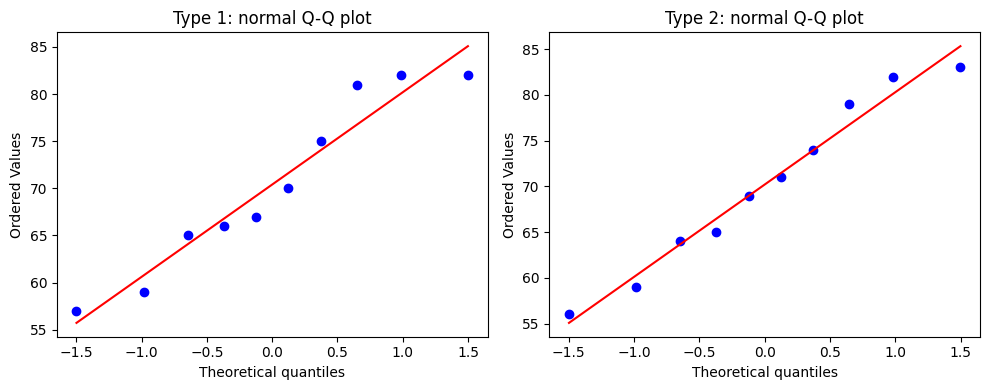

Shapiro-Wilk Type 1: W=0.9136, p=0.3065
Shapiro-Wilk Type 2: W=0.9548, p=0.7251


In [80]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(x26, dist="norm", plot=ax[0])
ax[0].set_title("Type 1: normal Q-Q plot")
stats.probplot(y26, dist="norm", plot=ax[1])
ax[1].set_title("Type 2: normal Q-Q plot")
plt.tight_layout()
plt.show()

W1_26, pW1_26 = shapiro(x26)
W2_26, pW2_26 = shapiro(y26)
print(f"Shapiro-Wilk Type 1: W={W1_26:.4f}, p={pW1_26:.4f}")
print(f"Shapiro-Wilk Type 2: W={W2_26:.4f}, p={pW2_26:.4f}")

In [81]:
power_analysis = TTestIndPower()

# Power to detect a true difference of 2 minutes, using the estimated common SD.
effect_2min_26 = 2.0 / sp_26
power_2min_26 = power_analysis.power(effect_size=effect_2min_26, nobs1=n1_26, ratio=1.0, alpha=0.05, alternative="two-sided")

# Required n per group to detect a true difference of 1 minute with power >= 0.90.
effect_1min_26 = 1.0 / sp_26
required_n26 = power_analysis.solve_power(effect_size=effect_1min_26, alpha=0.05, power=0.90, ratio=1.0, alternative="two-sided")
required_n26_int = int(np.ceil(required_n26))
check_power26 = power_analysis.power(effect_size=effect_1min_26, nobs1=required_n26_int, ratio=1.0, alpha=0.05, alternative="two-sided")

print(f"Power to detect Delta=2 min with n=10 per group = {power_2min_26:.4f}")
print(f"Required n per group for Delta=1 min and power >= 0.90 = {required_n26_int}")
print(f"Power at n={required_n26_int} = {check_power26:.4f}")

Power to detect Delta=2 min with n=10 per group = 0.0740
Required n per group for Delta=1 min and power >= 0.90 = 1825
Power at n=1825 = 0.9001


The variance test gives $F\approx0.978$ with $p\approx0.974$, so there is no evidence that the two variances differ, which leads us to the pooled mean test. The mean test produces $t\approx0.0480$ with $p\approx0.9622$, providing no evidence of a difference in the mean burning time. The Q-Q plots and Shapiro-Wilk p-values (about 0.307 and 0.725) reveal no serious normality problem in neither case. Normality is important for the $F$ test, which assumes normality. With the estimated common SD, the power to detect a 2 minute difference is only about 0.074. Detecting a minute difference with at least 0.90 power would require roughly 1825 flares per formulation, because a minute difference is very tiny relative to the observed SD (which is about 9.32 minutes).

### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [82]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


A larger appearance score means fewer defects, so the claim that the longer cool-down time is better corresponds to
$$
H_0:\mu_{20}\le\mu_{10},\qquad H_1:\mu_{20}>\mu_{10}.
$$
Using a one-sided pooled two-sample $t$-test (if we have equal variance). The reported 95% confidence interval is the usual two sided interval for $\mu_{20}-\mu_{10}$ and then a lower bound interval for the aforementioned difference (which I would probably consider the main one?). Power is computed for the same one-sided alternative, using the observed mean difference and pooled standard deviation as planning values.

In [83]:
# Exercise 2.30: hypothesis test and confidence interval
x10 = df30["10 seconds"].to_numpy(dtype=float)
x20cool = df30["20 seconds"].to_numpy(dtype=float)
n10, n20cool = len(x10), len(x20cool)
mean10, mean20cool = np.mean(x10), np.mean(x20cool)
var10, var20cool = np.var(x10, ddof=1), np.var(x20cool, ddof=1)

# Supplementary variance check
F30 = var10 / var20cool
pF30 = 2 * min(stats.f.cdf(F30, n10-1, n20cool-1), stats.f.sf(F30, n10-1, n20cool-1))

sp2_30 = ((n10-1)*var10 + (n20cool-1)*var20cool)/(n10+n20cool-2)
sp_30 = np.sqrt(sp2_30)
diff30 = mean20cool - mean10
se30 = sp_30 * np.sqrt(1/n10 + 1/n20cool)
df_30 = n10 + n20cool - 2
t30 = diff30 / se30
p30 = stats.t.sf(t30, df_30)   # one-sided H1: mu20 > mu10
ci30 = stats.t.interval(0.95, df=df_30, loc=diff30, scale=se30)

print(f"Mean at 10 s = {mean10:.3f}")
print(f"Mean at 20 s = {mean20cool:.3f}")
print(f"Estimated improvement (mu20-mu10) = {diff30:.3f} score points")
print(f"Pooled SD = {sp_30:.4f}")
print(f"Supplementary F-test for equal variances: F={F30:.4f}, p={pF30:.4f}")
print(f"t = {t30:.4f}, df = {df_30}, one-sided p-value = {p30:.8f}")
print(f"95% CI for mu20-mu10 = ({ci30[0]:.4f}, {ci30[1]:.4f})")

Mean at 10 s = 3.350
Mean at 20 s = 6.500
Estimated improvement (mu20-mu10) = 3.150 score points
Pooled SD = 1.7885
Supplementary F-test for equal variances: F=1.7011, p=0.2559
t = 5.5696, df = 38, one-sided p-value = 0.00000111
95% CI for mu20-mu10 = (2.0051, 4.2949)


In [87]:
# Calculate the 95% Lower One-Sided Confidence Bound for mu20 - mu10
alpha30 = 0.05
t_crit_30 = stats.t.ppf(1 - alpha30, df=df_30)

lower_bound_30 = diff30 - t_crit_30 * se30

print(f"95% Lower One-Sided Confidence Interval: [{lower_bound_30:.4f}, +inf) score points")

95% Lower One-Sided Confidence Interval: [2.1965, +inf) score points


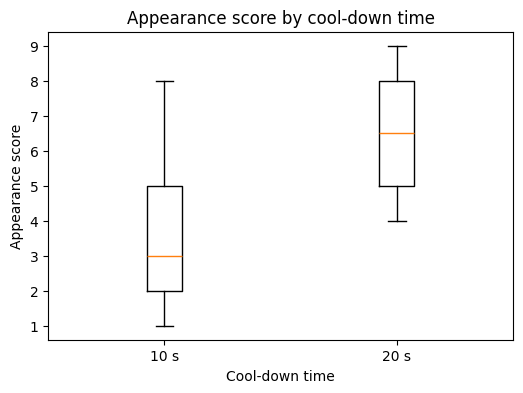

In [84]:
# Exercise 2.30: visualization of the two groups
plt.figure(figsize=(6, 4))
plt.boxplot([x10, x20cool], tick_labels=["10 s", "20 s"])
plt.xlabel("Cool-down time")
plt.ylabel("Appearance score")
plt.title("Appearance score by cool-down time")
plt.show()

In [85]:
# Exercise 2.30: power of the one-sided test
power_analysis = TTestIndPower()
effect30 = diff30 / sp_30
power30 = power_analysis.power(effect_size=effect30, nobs1=n20cool, ratio=n10/n20cool, alpha=0.05, alternative="larger")
print(f"Observed standardized effect d = {effect30:.4f}")
print(f"Power of the one-sided test with n=20 per group = {power30:.6f}")

Observed standardized effect d = 1.7613
Power of the one-sided test with n=20 per group = 0.999934


The average score rises from 3.35 at 10 s to 6.50 at 20 s, an estimated improvement of 3.15 points. The one-sided pooled $t$ test gives $t\approx5.570$ and $p\approx1.11\times10^{-6}$, so there is very strong evidence at $\alpha=0.05$ that the longer cool-down time produces higher appearance scores (fewer defects). The 95% two sided CI for $\mu_{20}-\mu_{10}$ is approximately $(2.005,4.295)$ points and the one sided lower bound CI is
With $95\%$ confidence $(2.196, +\infty)$. The longer cool-down time (20 seconds) thus improves the mean appearance score by at least 2.20 score points compared to the 10-second cool-down time. I would say that this strongly supports rejecting $H_0$ in favor of $H_1$. If I were to interpret the second CI, the 20-second process is estimated to improve the mean appearance score by about 2.0 to 4.3 points. Using the observed effect as the planning value, the one-sided test has power approximately 0.99993.